# 第6章：Fine-tuning for Classification

**目标：** 将预训练好的 GPT 模型改造为**垃圾短信分类器**，学习分类微调的完整流程

```
微调类型概览 → 准备数据集 → 创建 DataLoader → 加载预训练权重 → 添加分类头 → 训练 → 评估 → 使用
```

**前置回顾（第2-5章）：**
- 第2章：文本 → Token IDs → DataLoader
- 第3章：Causal Multi-Head Attention
- 第4章：完整 GPT 模型架构
- 第5章：预训练 + 加载 GPT-2 权重 + 文本生成
- 现在的问题：预训练模型只会「续写」文本，**不能做分类** → **需要微调！**

---

## 6.1 微调的类型 ⭐

LLM 最常见的两种微调方式：

| 类型 | 目标 | 输出 | 代表应用 |
|------|------|------|----------|
| **分类微调（Classification）** | 让模型输出固定的类别标签 | `spam` / `not spam` | 情感分析、垃圾邮件检测 |
| **指令微调（Instruction）** | 让模型按指令生成文本 | 自由文本 | ChatGPT 式对话 |

**本章聚焦分类微调：**
- 分类微调 = 给模型加一个「分类头」，输出**固定数量的类别**
- 模型只能预测训练过程中见过的类别（例如 spam / not spam）
- 相比指令微调，分类模型更加**专注**，通常也更容易训练

> 💡 **关键洞察：** 分类微调类似于用 CNN 做手写数字分类——都是替换输出层，冻结骨干网络，然后用有标签数据训练。

指令微调将在**第7章**详细讨论。

---

## 6.2 准备数据集 ⭐⭐

我们使用 **SMS Spam Collection** 数据集——包含 5,572 条短信，标注为 `ham`（正常）或 `spam`（垃圾）。

**数据处理流程：**
1. 下载并解压数据
2. 加载为 pandas DataFrame
3. 平衡类别（欠采样多数类）
4. 转换标签：`ham → 0`，`spam → 1`
5. 划分训练/验证/测试集（70%/10%/20%）

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import tiktoken
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = ['Arial Unicode MS']
matplotlib.rcParams['axes.unicode_minus'] = False
import numpy as np
import os

# ─── 第4章的所有组件（直接复用）───────────────────────────────────

# GPT-2 Small (124M) 的超参数配置
GPT_CONFIG_124M = {
    "vocab_size": 50257,      # BPE 词汇表大小
    "context_length": 1024,   # 最大序列长度（位置编码上限）
    "emb_dim": 768,           # 嵌入维度 / 隐藏层维度
    "n_heads": 12,            # 多头注意力的头数（每头 768/12=64 维）
    "n_layers": 12,           # Transformer Block 堆叠层数
    "drop_rate": 0.1,         # Dropout 概率
    "qkv_bias": False,        # Q/K/V 线性投影是否带偏置项
}


class MultiHeadAttention(nn.Module):
    """多头因果自注意力（第3章）"""
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert d_out % num_heads == 0, "d_out 必须能被 num_heads 整除"
        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)
        self.dropout  = nn.Dropout(dropout)

        self.register_buffer(
            'mask',
            torch.triu(torch.ones(context_length, context_length), diagonal=1)
        )

    def forward(self, x):
        b, num_tokens, d_in = x.shape
        queries = self.W_query(x)
        keys    = self.W_key(x)
        values  = self.W_value(x)

        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        keys    = keys.view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        values  = values.view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)

        attn_scores = queries @ keys.transpose(2, 3)
        attn_scores.masked_fill_(
            self.mask[:num_tokens, :num_tokens].bool(), -torch.inf
        )
        attn_weights = F.softmax(attn_scores / self.head_dim**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        context_vecs = attn_weights @ values
        context_vecs = context_vecs.transpose(1, 2).contiguous().view(b, num_tokens, self.d_out)
        context_vecs = self.out_proj(context_vecs)
        return context_vecs


class LayerNorm(nn.Module):
    """层归一化（第4章）"""
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift


class GELU(nn.Module):
    """GELU 激活函数（第4章）"""
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) *
            (x + 0.044715 * torch.pow(x, 3))
        ))


class FeedForward(nn.Module):
    """前馈网络（第4章）"""
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
        )

    def forward(self, x):
        return self.layers(x)


class TransformerBlock(nn.Module):
    """Transformer Block（第4章）"""
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"], d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"], dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"],
        )
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)
        x = self.drop_shortcut(x)
        x = x + shortcut

        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut
        return x


class GPTModel(nn.Module):
    """完整 GPT 模型（第4章）"""
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])]
        )

        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits


def generate_text_simple(model, idx, max_new_tokens, context_size):
    """贪心解码文本生成（第4章）"""
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:, -1, :]
        probas = torch.softmax(logits, dim=-1)
        idx_next = torch.argmax(probas, dim=-1, keepdim=True)
        idx = torch.cat((idx, idx_next), dim=1)
    return idx


# ─── 第5章的权重加载工具 ─────────────────────────────────────────

def assign(left, right):
    """将 numpy 权重赋值给 PyTorch 参数"""
    if left.shape != right.shape:
        raise ValueError(f"Shape 不匹配: {left.shape} vs {right.shape}")
    return nn.Parameter(torch.tensor(right))


def load_weights_into_gpt(gpt, params):
    """将 Hugging Face GPT-2 权重加载到我们的 GPTModel 中（第5章）"""
    gpt.tok_emb.weight = assign(gpt.tok_emb.weight, params["wte.weight"])
    gpt.pos_emb.weight = assign(gpt.pos_emb.weight, params["wpe.weight"])

    for b in range(len(gpt.trf_blocks)):
        q_w, k_w, v_w = np.split(
            params[f"h.{b}.attn.c_attn.weight"], 3, axis=-1
        )
        gpt.trf_blocks[b].att.W_query.weight = assign(
            gpt.trf_blocks[b].att.W_query.weight, q_w.T
        )
        gpt.trf_blocks[b].att.W_key.weight = assign(
            gpt.trf_blocks[b].att.W_key.weight, k_w.T
        )
        gpt.trf_blocks[b].att.W_value.weight = assign(
            gpt.trf_blocks[b].att.W_value.weight, v_w.T
        )

        q_b, k_b, v_b = np.split(
            params[f"h.{b}.attn.c_attn.bias"], 3, axis=-1
        )
        gpt.trf_blocks[b].att.W_query.bias = assign(
            gpt.trf_blocks[b].att.W_query.bias, q_b
        )
        gpt.trf_blocks[b].att.W_key.bias = assign(
            gpt.trf_blocks[b].att.W_key.bias, k_b
        )
        gpt.trf_blocks[b].att.W_value.bias = assign(
            gpt.trf_blocks[b].att.W_value.bias, v_b
        )

        gpt.trf_blocks[b].att.out_proj.weight = assign(
            gpt.trf_blocks[b].att.out_proj.weight,
            params[f"h.{b}.attn.c_proj.weight"].T
        )
        gpt.trf_blocks[b].att.out_proj.bias = assign(
            gpt.trf_blocks[b].att.out_proj.bias,
            params[f"h.{b}.attn.c_proj.bias"]
        )

        gpt.trf_blocks[b].ff.layers[0].weight = assign(
            gpt.trf_blocks[b].ff.layers[0].weight,
            params[f"h.{b}.mlp.c_fc.weight"].T
        )
        gpt.trf_blocks[b].ff.layers[0].bias = assign(
            gpt.trf_blocks[b].ff.layers[0].bias,
            params[f"h.{b}.mlp.c_fc.bias"]
        )
        gpt.trf_blocks[b].ff.layers[2].weight = assign(
            gpt.trf_blocks[b].ff.layers[2].weight,
            params[f"h.{b}.mlp.c_proj.weight"].T
        )
        gpt.trf_blocks[b].ff.layers[2].bias = assign(
            gpt.trf_blocks[b].ff.layers[2].bias,
            params[f"h.{b}.mlp.c_proj.bias"]
        )

        gpt.trf_blocks[b].norm1.scale = assign(
            gpt.trf_blocks[b].norm1.scale,
            params[f"h.{b}.ln_1.weight"]
        )
        gpt.trf_blocks[b].norm1.shift = assign(
            gpt.trf_blocks[b].norm1.shift,
            params[f"h.{b}.ln_1.bias"]
        )
        gpt.trf_blocks[b].norm2.scale = assign(
            gpt.trf_blocks[b].norm2.scale,
            params[f"h.{b}.ln_2.weight"]
        )
        gpt.trf_blocks[b].norm2.shift = assign(
            gpt.trf_blocks[b].norm2.shift,
            params[f"h.{b}.ln_2.bias"]
        )

    gpt.final_norm.scale = assign(gpt.final_norm.scale, params["ln_f.weight"])
    gpt.final_norm.shift = assign(gpt.final_norm.shift, params["ln_f.bias"])
    gpt.out_head.weight = assign(gpt.out_head.weight, params["wte.weight"])


def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    return torch.tensor(encoded).unsqueeze(0)


def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0)
    return tokenizer.decode(flat.tolist())


# ─── 初始化 ────────────────────────────────────────────────────
tokenizer = tiktoken.get_encoding("gpt2")
print("第4-5章组件加载完毕 ✓")

第4-5章组件加载完毕 ✓


### 下载并加载 SMS Spam 数据集

In [2]:
import urllib.request
import zipfile
from pathlib import Path
import pandas as pd

url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
zip_path = "sms_spam_collection.zip"
extracted_path = "sms_spam_collection"
data_file_path = Path(extracted_path) / "SMSSpamCollection.tsv"


def download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path):
    if data_file_path.exists():
        print(f"{data_file_path} 已存在，跳过下载。")
        return

    with urllib.request.urlopen(url) as response:
        with open(zip_path, "wb") as out_file:
            out_file.write(response.read())

    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extracted_path)

    original_file_path = Path(extracted_path) / "SMSSpamCollection"
    os.rename(original_file_path, data_file_path)
    print(f"文件已下载并保存为 {data_file_path}")


download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path)

sms_spam_collection/SMSSpamCollection.tsv 已存在，跳过下载。


In [3]:
df = pd.read_csv(data_file_path, sep="\t", header=None, names=["Label", "Text"])
print(f"→ 数据集大小: {len(df)} 条短信")
print(f"→ 类别分布:\n{df['Label'].value_counts()}")
df.head()

→ 数据集大小: 5572 条短信
→ 类别分布:
Label
ham     4825
spam     747
Name: count, dtype: int64


,Label,Text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


### 平衡数据集

数据集中 ham（正常）远多于 spam（垃圾），我们通过**欠采样（undersampling）** 使两类数量相等。

In [4]:
def create_balanced_dataset(df):
    num_spam = df[df["Label"] == "spam"].shape[0]
    ham_subset = df[df["Label"] == "ham"].sample(num_spam, random_state=123)
    balanced_df = pd.concat([ham_subset, df[df["Label"] == "spam"]])
    return balanced_df


balanced_df = create_balanced_dataset(df)
print(f"→ 平衡后类别分布:\n{balanced_df['Label'].value_counts()}")

→ 平衡后类别分布:
Label
ham     747
spam    747
Name: count, dtype: int64


In [5]:
# 将字符串标签转为整数：ham → 0, spam → 1
balanced_df["Label"] = balanced_df["Label"].map({"ham": 0, "spam": 1})
balanced_df.head()

,Label,Text
4307,0,Awww dat is sweet! We can think of something t...
4138,0,Just got to &lt;#&gt;
4831,0,"The word ""Checkmate"" in chess comes from the P..."
4461,0,This is wishing you a great day. Moji told me ...
5440,0,Thank you. do you generally date the brothas?


### 划分训练/验证/测试集

In [6]:
def random_split(df, train_frac, validation_frac):
    df = df.sample(frac=1, random_state=123).reset_index(drop=True)
    train_end = int(len(df) * train_frac)
    validation_end = train_end + int(len(df) * validation_frac)

    train_df = df[:train_end]
    validation_df = df[train_end:validation_end]
    test_df = df[validation_end:]
    return train_df, validation_df, test_df


train_df, validation_df, test_df = random_split(balanced_df, 0.7, 0.1)

train_df.to_csv("train.csv", index=None)
validation_df.to_csv("validation.csv", index=None)
test_df.to_csv("test.csv", index=None)

print(f"→ 训练集: {len(train_df)} | 验证集: {len(validation_df)} | 测试集: {len(test_df)}")

→ 训练集: 1045 | 验证集: 149 | 测试集: 300


### ✏️ 练习

1. 查看 `balanced_df` 中最长和最短的短信各有多少个词？多少个 token？
2. 如果不做欠采样，直接用不平衡的数据训练，模型会出现什么问题？
3. **进阶**：除了欠采样，还有哪些处理类别不平衡的方法？试着搜索 `imbalanced-learn` 库。

In [7]:
# 练习 1：统计最长/最短短信的词数和 token 数
balanced_df_stats = balanced_df.copy()
balanced_df_stats["word_count"] = balanced_df_stats["Text"].str.split().str.len()
balanced_df_stats["token_count"] = balanced_df_stats["Text"].apply(lambda text: len(tokenizer.encode(text)))

longest_by_words = balanced_df_stats.loc[balanced_df_stats["word_count"].idxmax()]
shortest_by_words = balanced_df_stats.loc[balanced_df_stats["word_count"].idxmin()]
longest_by_tokens = balanced_df_stats.loc[balanced_df_stats["token_count"].idxmax()]
shortest_by_tokens = balanced_df_stats.loc[balanced_df_stats["token_count"].idxmin()]

print("按词数统计:")
print(f"  最长短信: {longest_by_words['word_count']} 个词, {longest_by_words['token_count']} 个 token")
print(f"  内容预览: {longest_by_words['Text'][:120]}...")
print(f"  最短短信: {shortest_by_words['word_count']} 个词, {shortest_by_words['token_count']} 个 token")
print(f"  内容预览: {shortest_by_words['Text']}")

print("\n按 token 数统计:")
print(f"  最长短信: {longest_by_tokens['word_count']} 个词, {longest_by_tokens['token_count']} 个 token")
print(f"  内容预览: {longest_by_tokens['Text'][:120]}...")
print(f"  最短短信: {shortest_by_tokens['word_count']} 个词, {shortest_by_tokens['token_count']} 个 token")
print(f"  内容预览: {shortest_by_tokens['Text']}")

print("\n思考题答案:")
print("1. 不做欠采样时，模型容易偏向多数类 ham；即使总体 accuracy 很高，也可能漏判 spam。")
print("2. 处理类别不平衡还可以用过采样、SMOTE、class_weight、focal loss、阈值调整或分层采样。")
print("3. imbalanced-learn 提供 RandomOverSampler、RandomUnderSampler、SMOTE 等常用方法。")

按词数统计:
  最长短信: 95 个词, 104 个 token
  内容预览: Hey sweet, I was wondering when you had a moment if you might come to me ? I want to send a file to someone but it won't...
  最短短信: 1 个词, 2 个 token
  内容预览: Ok..

按 token 数统计:
  最长短信: 79 个词, 120 个 token
  内容预览: Storming msg: Wen u lift d phne, u say "HELLO" Do u knw wt is d real meaning of HELLO?? . . . It's d name of a girl..! ....
  最短短信: 1 个词, 2 个 token
  内容预览: Ok..

思考题答案:
1. 不做欠采样时，模型容易偏向多数类 ham；即使总体 accuracy 很高，也可能漏判 spam。
2. 处理类别不平衡还可以用过采样、SMOTE、class_weight、focal loss、阈值调整或分层采样。
3. imbalanced-learn 提供 RandomOverSampler、RandomUnderSampler、SMOTE 等常用方法。


---

## 6.3 创建 DataLoader ⭐⭐

不同短信长度不一，需要**填充（padding）**到统一长度才能组成 batch。

**策略：**
- 用 `<|endoftext|>`（token ID = 50256）作为 padding token
- 所有序列填充到训练集中最长的序列长度
- 超过最大长度的序列会被截断

In [8]:
from torch.utils.data import Dataset, DataLoader


class SpamDataset(Dataset):
    def __init__(self, csv_file, tokenizer, max_length=None, pad_token_id=50256):
        self.data = pd.read_csv(csv_file)

        # 预先分词
        self.encoded_texts = [
            tokenizer.encode(text) for text in self.data["Text"]
        ]

        if max_length is None:
            self.max_length = self._longest_encoded_length()
        else:
            self.max_length = max_length
            # 截断超长序列
            self.encoded_texts = [
                encoded_text[:self.max_length]
                for encoded_text in self.encoded_texts
            ]

        # 填充到统一长度
        self.encoded_texts = [
            encoded_text + [pad_token_id] * (self.max_length - len(encoded_text))
            for encoded_text in self.encoded_texts
        ]

    def __getitem__(self, index):
        encoded = self.encoded_texts[index]
        label = self.data.iloc[index]["Label"]
        return (
            torch.tensor(encoded, dtype=torch.long),
            torch.tensor(label, dtype=torch.long)
        )

    def __len__(self):
        return len(self.data)

    def _longest_encoded_length(self):
        return max(len(encoded_text) for encoded_text in self.encoded_texts)

In [9]:
# 创建三个数据集
train_dataset = SpamDataset(csv_file="train.csv", max_length=None, tokenizer=tokenizer)
print(f"→ 训练集最长序列: {train_dataset.max_length} tokens")

val_dataset = SpamDataset(
    csv_file="validation.csv", max_length=train_dataset.max_length, tokenizer=tokenizer
)
test_dataset = SpamDataset(
    csv_file="test.csv", max_length=train_dataset.max_length, tokenizer=tokenizer
)

→ 训练集最长序列: 120 tokens


In [10]:
# 创建 DataLoader
num_workers = 0
batch_size = 8

torch.manual_seed(123)

train_loader = DataLoader(
    dataset=train_dataset, batch_size=batch_size,
    shuffle=True, num_workers=num_workers, drop_last=True,
)
val_loader = DataLoader(
    dataset=val_dataset, batch_size=batch_size,
    num_workers=num_workers, drop_last=False,
)
test_loader = DataLoader(
    dataset=test_dataset, batch_size=batch_size,
    num_workers=num_workers, drop_last=False,
)

# 验证 batch 维度
for input_batch, target_batch in train_loader:
    pass
print(f"→ 输入 batch: {input_batch.shape}")
print(f"→ 标签 batch: {target_batch.shape}")
print(f"→ {len(train_loader)} 训练 batches | {len(val_loader)} 验证 batches | {len(test_loader)} 测试 batches")

→ 输入 batch: torch.Size([8, 120])
→ 标签 batch: torch.Size([8])
→ 130 训练 batches | 19 验证 batches | 38 测试 batches


### ✏️ 练习

1. 改变 `batch_size`（如 4、16、32），观察 batch 数量的变化。更大的 batch_size 有什么利弊？
2. 如果不做 padding，直接用变长序列训练，会遇到什么问题？
3. **进阶**：当前我们把所有序列 pad 到数据集最长长度。能否改为 pad 到**每个 batch 的最长长度**？这样做有什么好处？

In [11]:
# 练习 1：观察不同 batch_size 对 batch 数量的影响
def count_batches_for_batch_size(batch_size):
    loader = DataLoader(
        dataset=train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
        drop_last=True,
    )
    return len(loader)

for candidate_batch_size in [4, 8, 16, 32]:
    print(f"batch_size={candidate_batch_size:>2} → {count_batches_for_batch_size(candidate_batch_size)} 个训练 batch")

print("\n更大的 batch_size 通常训练更稳定、吞吐更高，但显存占用更大，参数更新次数更少，泛化有时会变差。")


# 练习 2：不 padding 时，默认 DataLoader 无法把变长序列堆叠成一个张量
class SpamDatasetNoPadding(Dataset):
    def __init__(self, csv_file, tokenizer):
        self.data = pd.read_csv(csv_file)
        self.encoded_texts = [tokenizer.encode(text) for text in self.data["Text"]]

    def __getitem__(self, index):
        return (
            torch.tensor(self.encoded_texts[index], dtype=torch.long),
            torch.tensor(self.data.iloc[index]["Label"], dtype=torch.long),
        )

    def __len__(self):
        return len(self.data)

raw_train_dataset = SpamDatasetNoPadding("train.csv", tokenizer)
raw_loader = DataLoader(raw_train_dataset, batch_size=4, shuffle=False)

try:
    next(iter(raw_loader))
except RuntimeError as err:
    print("\n不 padding 的默认 collate 会报错:")
    print(f"  {str(err).splitlines()[0]}")


# 练习 3：按每个 batch 的最长序列动态 padding
from torch.nn.utils.rnn import pad_sequence

def dynamic_padding_collate_fn(batch, pad_token_id=50256):
    input_ids, labels = zip(*batch)
    padded_input_ids = pad_sequence(
        input_ids,
        batch_first=True,
        padding_value=pad_token_id,
    )
    return padded_input_ids, torch.stack(labels)

dynamic_train_loader = DataLoader(
    raw_train_dataset,
    batch_size=8,
    shuffle=True,
    collate_fn=dynamic_padding_collate_fn,
)

dynamic_input_batch, dynamic_target_batch = next(iter(dynamic_train_loader))
print("\n动态 padding batch:")
print(f"  输入 shape: {dynamic_input_batch.shape}")
print(f"  标签 shape: {dynamic_target_batch.shape}")
print(f"  固定 padding 长度: {train_dataset.max_length}")
print(f"  当前 batch 动态 padding 长度: {dynamic_input_batch.shape[1]}")
print("  好处: 减少无效 padding token，通常能降低计算量和显存占用。")

batch_size= 4 → 261 个训练 batch
batch_size= 8 → 130 个训练 batch
batch_size=16 → 65 个训练 batch
batch_size=32 → 32 个训练 batch

更大的 batch_size 通常训练更稳定、吞吐更高，但显存占用更大，参数更新次数更少，泛化有时会变差。

不 padding 的默认 collate 会报错:
  stack expects each tensor to be equal size, but got [10] at entry 0 and [35] at entry 1

动态 padding batch:
  输入 shape: torch.Size([8, 50])
  标签 shape: torch.Size([8])
  固定 padding 长度: 120
  当前 batch 动态 padding 长度: 50
  好处: 减少无效 padding token，通常能降低计算量和显存占用。


---

## 6.4 加载预训练权重 ⭐⭐

我们复用第5章的做法，从 Hugging Face 下载 GPT-2 (124M) 的预训练权重并加载到模型中。

**关键配置变化：**
- `drop_rate` 设为 **0.0**（微调时不需要太多 dropout）
- `qkv_bias` 设为 **True**（GPT-2 原版带偏置）

In [12]:
# 必须在导入 transformers / huggingface_hub 之前设置镜像和超时。
# 如果你之前已经运行过 transformers 相关单元，建议重启 kernel 后从头运行。
import os

USE_HF_MIRROR = True
if USE_HF_MIRROR:
    os.environ["HF_ENDPOINT"] = "https://hf-mirror.com"

# 增加连接和下载超时时间，降低大文件下载时中断的概率。
os.environ["HF_HUB_ETAG_TIMEOUT"] = "60"
os.environ["HF_HUB_DOWNLOAD_TIMEOUT"] = "300"

from transformers import GPT2Model as HF_GPT2Model


def _load_hf_gpt2(model_size, models_dir, local_files_only):
    return HF_GPT2Model.from_pretrained(
        model_size,
        cache_dir=models_dir,
        local_files_only=local_files_only,
    )


def download_and_load_gpt2(model_size, models_dir, local_files_only="auto"):
    """从本地缓存、Hugging Face 或镜像站加载 GPT-2 权重。

    local_files_only:
    - "auto": 优先读本地缓存；缓存不存在时再联网下载
    - True: 只读本地缓存
    - False: 允许联网下载
    """
    print(f"HF_ENDPOINT = {os.environ.get('HF_ENDPOINT', 'https://huggingface.co')}")
    print(f"cache_dir = {models_dir}")
    print(f"local_files_only = {local_files_only}")

    try:
        if local_files_only == "auto":
            try:
                print("先尝试从本地缓存加载...")
                model_hf = _load_hf_gpt2(model_size, models_dir, local_files_only=True)
                print("已从本地缓存加载。")
            except OSError:
                print("本地缓存不存在或不完整，改为从网络下载...")
                model_hf = _load_hf_gpt2(model_size, models_dir, local_files_only=False)
        else:
            model_hf = _load_hf_gpt2(model_size, models_dir, local_files_only=local_files_only)
    except OSError as e:
        print("\n模型权重加载失败。")
        print("可尝试的处理方式:")
        print("1. 重启 Jupyter kernel，然后从头运行，确保 HF_ENDPOINT 在 transformers 导入前生效。")
        print("2. 如果之前已成功下载过，把 local_files_only=True，只读本地缓存。")
        print("3. 如果镜像不可用，把 USE_HF_MIRROR=False，改回官方 huggingface.co。")
        raise e

    model_hf.eval()
    params = {}
    for name, param in model_hf.named_parameters():
        params[name] = param.detach().numpy()
    for name, buf in model_hf.named_buffers():
        params[name] = buf.detach().numpy()
    return params


CHOOSE_MODEL = "gpt2"

BASE_CONFIG = {
    "vocab_size": 50257,
    "context_length": 1024,
    "drop_rate": 0.0,        # 微调时 dropout 设为 0
    "qkv_bias": True,        # GPT-2 原版带偏置
    "emb_dim": 768,
    "n_layers": 12,
    "n_heads": 12,
}

assert train_dataset.max_length <= BASE_CONFIG["context_length"], (
    f"数据集长度 {train_dataset.max_length} 超过模型上下文长度 {BASE_CONFIG['context_length']}"
)

/Users/huanxin/Desktop/个人/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [13]:
# 下载并加载权重
models_dir = os.path.join("..", "models", CHOOSE_MODEL)
os.makedirs(models_dir, exist_ok=True)

print(f"正在加载 {CHOOSE_MODEL} 模型...")
params = download_and_load_gpt2(
    CHOOSE_MODEL,
    models_dir,
    local_files_only="auto",  # 优先读缓存；没有缓存再从镜像/官方站下载
)
print(f"加载完成！参数数量: {len(params)}")

model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
model.eval()
print("\n预训练权重加载完毕 ✓")

正在加载 gpt2 模型...
HF_ENDPOINT = https://hf-mirror.com
cache_dir = ../models/gpt2
local_files_only = auto
先尝试从本地缓存加载...


Loading weights: 100%|██████████| 148/148 [00:00<00:00, 13830.87it/s]

已从本地缓存加载。
加载完成！参数数量: 148



预训练权重加载完毕 ✓


### 验证权重：让模型生成文本

In [14]:
# 验证模型可以生成连贯文本
text = "Every effort moves you"
token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(text, tokenizer),
    max_new_tokens=15,
    context_size=BASE_CONFIG["context_length"]
)
print(f"→ 输入: {text}")
print(f"→ 生成: {token_ids_to_text(token_ids, tokenizer)}")

→ 输入: Every effort moves you
→ 生成: Every effort moves you forward.

The first step is to understand the importance of your work


### 试试用 prompt 做分类？

在微调之前，先看看预训练模型能否直接通过 prompt 来判断垃圾短信：

In [15]:
text = (
    "Is the following text 'spam'? Answer with 'yes' or 'no':"
    " 'You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award.'"
)

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(text, tokenizer),
    max_new_tokens=23,
    context_size=BASE_CONFIG["context_length"]
)
print(token_ids_to_text(token_ids, tokenizer))

Is the following text 'spam'? Answer with 'yes' or 'no': 'You are a winner you have been specially selected to receive $1000 cash or a $2000 award.'

The following text 'spam'? Answer with 'yes' or 'no': 'You are a winner


> 💡 **观察：** 预训练模型并不擅长「遵循指令」——它只会续写文本，不会回答 yes/no 问题。
> 这正是我们需要**微调**的原因！指令微调会在第7章介绍。

---

## 6.5 添加分类头 ⭐⭐⭐

这是本章的**核心步骤**：

1. **冻结所有参数** — 让预训练权重不被破坏
2. **替换 `out_head`** — 从 50,257 维（词汇表）→ 2 维（spam / not spam）
3. **解冻最后一层 Transformer Block + final_norm** — 适度微调提升效果

```
为什么用最后一个 token 做分类？

在 Causal Attention 中，每个 token 只能看到自己和之前的 token。
因此最后一个 token 拥有整个序列的信息 → 最适合做分类判断。
```

In [16]:
# 第一步：冻结所有参数
for param in model.parameters():
    param.requires_grad = False

# 第二步：替换输出层 (50,257 → 2)
torch.manual_seed(123)
num_classes = 2
model.out_head = torch.nn.Linear(
    in_features=BASE_CONFIG["emb_dim"],
    out_features=num_classes
)

# 第三步：解冻最后一层 Transformer Block 和 final_norm
for param in model.trf_blocks[-1].parameters():
    param.requires_grad = True
for param in model.final_norm.parameters():
    param.requires_grad = True

# 统计可训练参数
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"→ 总参数: {total_params:,}")
print(f"→ 可训练参数: {trainable_params:,} ({trainable_params/total_params*100:.1f}%)")

→ 总参数: 124,441,346
→ 可训练参数: 7,090,946 (5.7%)


### 验证新的输出维度

In [17]:
inputs = tokenizer.encode("Do you have time")
inputs = torch.tensor(inputs).unsqueeze(0)
print(f"→ 输入: {inputs}, shape: {inputs.shape}")

with torch.no_grad():
    outputs = model(inputs)
print(f"→ 输出 shape: {outputs.shape}  (batch=1, seq=4, classes=2)")

# 取最后一个 token 的输出作为分类依据
print(f"→ 最后一个 token 的 logits: {outputs[:, -1, :]}")

→ 输入: tensor([[5211,  345,  423,  640]]), shape: torch.Size([1, 4])
→ 输出 shape: torch.Size([1, 4, 2])  (batch=1, seq=4, classes=2)
→ 最后一个 token 的 logits: tensor([[-3.5983,  3.9902]])


### ✏️ 练习

1. 如果只训练 `out_head`（不解冻最后一层 TransformerBlock），准确率会下降多少？
2. 如果解冻**所有**层（full fine-tuning），训练速度和效果会怎样？
3. **进阶**：搜索 LoRA（Low-Rank Adaptation），了解另一种参数高效微调方法。

In [18]:
# 练习：比较不同解冻策略下的可训练参数数量
# 注意：这里先只做参数规模对比，不改动主线正在使用的 model。
def make_classifier_from_pretrained(strategy):
    classifier = GPTModel(BASE_CONFIG)
    load_weights_into_gpt(classifier, params)

    for param in classifier.parameters():
        param.requires_grad = False

    torch.manual_seed(123)
    classifier.out_head = torch.nn.Linear(
        in_features=BASE_CONFIG["emb_dim"],
        out_features=2,
    )

    if strategy == "head_only":
        pass
    elif strategy == "last_block":
        for param in classifier.trf_blocks[-1].parameters():
            param.requires_grad = True
        for param in classifier.final_norm.parameters():
            param.requires_grad = True
    elif strategy == "full":
        for param in classifier.parameters():
            param.requires_grad = True
    else:
        raise ValueError(f"未知策略: {strategy}")

    return classifier

strategies = {
    "head_only": "只训练 out_head",
    "last_block": "训练 out_head + 最后一层 TransformerBlock + final_norm",
    "full": "解冻所有层",
}

for strategy, description in strategies.items():
    temp_model = make_classifier_from_pretrained(strategy)
    total_params = sum(p.numel() for p in temp_model.parameters())
    trainable_params = sum(p.numel() for p in temp_model.parameters() if p.requires_grad)
    print(f"{description:<45} 可训练参数: {trainable_params:>12,} ({trainable_params / total_params * 100:5.2f}%)")
    del temp_model

print("\n预期现象:")
print("1. head_only 最快、显存最省，但表达能力最弱，准确率通常低于解冻最后一层。")
print("2. full fine-tuning 最慢、最占显存，小数据集上更容易过拟合，但上限可能更高。")
print("3. LoRA 通过训练低秩适配矩阵来减少可训练参数，是常见的参数高效微调方法。")

只训练 out_head                                  可训练参数:        1,538 ( 0.00%)
训练 out_head + 最后一层 TransformerBlock + final_norm 可训练参数:    7,090,946 ( 5.70%)
解冻所有层                                         可训练参数:  124,441,346 (100.00%)

预期现象:
1. head_only 最快、显存最省，但表达能力最弱，准确率通常低于解冻最后一层。
2. full fine-tuning 最慢、最占显存，小数据集上更容易过拟合，但上限可能更高。
3. LoRA 通过训练低秩适配矩阵来减少可训练参数，是常见的参数高效微调方法。


---

## 6.6 计算分类损失和准确率 ⭐⭐

分类微调的评估指标：
- **交叉熵损失（Cross-Entropy Loss）** — 可微分，用于训练
- **分类准确率（Accuracy）** — 直观，用于评估

与第5章预训练的区别：
- 预训练时，我们优化**所有位置**的 next-token prediction loss
- 分类微调时，我们只取**最后一个 token** 的输出做分类

$$\text{Prediction} = \arg\max(\text{model}(x)[:, -1, :])$$

In [19]:
def calc_accuracy_loader(data_loader, model, device, num_batches=None):
    """计算整个 data_loader 上的分类准确率"""
    model.eval()
    correct_predictions, num_examples = 0, 0

    if num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))

    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            input_batch, target_batch = input_batch.to(device), target_batch.to(device)
            with torch.no_grad():
                logits = model(input_batch)[:, -1, :]  # 最后一个 token
            predicted_labels = torch.argmax(logits, dim=-1)
            num_examples += predicted_labels.shape[0]
            correct_predictions += (predicted_labels == target_batch).sum().item()
        else:
            break
    return correct_predictions / num_examples


def calc_loss_batch(input_batch, target_batch, model, device):
    """计算单个 batch 的交叉熵损失（只看最后一个 token）"""
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch)[:, -1, :]
    loss = F.cross_entropy(logits, target_batch)
    return loss


def calc_loss_loader(data_loader, model, device, num_batches=None):
    """计算整个 data_loader 上的平均损失"""
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches

In [20]:
# 选择设备
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"→ 使用设备: {device}")
model.to(device)

# 训练前的基线指标
torch.manual_seed(123)
with torch.no_grad():
    train_accuracy = calc_accuracy_loader(train_loader, model, device, num_batches=10)
    val_accuracy = calc_accuracy_loader(val_loader, model, device, num_batches=10)
    train_loss = calc_loss_loader(train_loader, model, device, num_batches=5)
    val_loss = calc_loss_loader(val_loader, model, device, num_batches=5)

print(f"\n训练前基线指标:")
print(f"  训练准确率: {train_accuracy*100:.2f}%")
print(f"  验证准确率: {val_accuracy*100:.2f}%")
print(f"  训练损失: {train_loss:.3f}")
print(f"  验证损失: {val_loss:.3f}")

→ 使用设备: cpu

训练前基线指标:
  训练准确率: 46.25%
  验证准确率: 45.00%
  训练损失: 3.075
  验证损失: 2.583


> 💡 **观察：** 训练前准确率大约在 50% 左右——相当于随机猜测。这很正常，因为分类头是随机初始化的。

---

## 6.7 训练分类器 ⭐⭐⭐

训练循环与第5章的 `train_model_simple` 基本相同，主要差异：
1. 跟踪 `examples_seen`（而非 `tokens_seen`）
2. 每个 epoch 后计算准确率（而非生成文本样本）

In [21]:
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss


def train_classifier_simple(model, train_loader, val_loader, optimizer, device,
                            num_epochs, eval_freq, eval_iter):
    train_losses, val_losses, train_accs, val_accs = [], [], [], []
    examples_seen, global_step = 0, -1

    for epoch in range(num_epochs):
        model.train()

        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward()
            optimizer.step()
            examples_seen += input_batch.shape[0]
            global_step += 1

            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")

        # 每个 epoch 结束后计算准确率
        train_accuracy = calc_accuracy_loader(train_loader, model, device, num_batches=eval_iter)
        val_accuracy = calc_accuracy_loader(val_loader, model, device, num_batches=eval_iter)
        print(f"Training accuracy: {train_accuracy*100:.2f}% | ", end="")
        print(f"Validation accuracy: {val_accuracy*100:.2f}%")
        train_accs.append(train_accuracy)
        val_accs.append(val_accuracy)

    return train_losses, val_losses, train_accs, val_accs, examples_seen

In [22]:
import time

# 🚀 开始训练！
start_time = time.time()

torch.manual_seed(123)
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.1)
num_epochs = 5

train_losses, val_losses, train_accs, val_accs, examples_seen = train_classifier_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=50, eval_iter=5,
)

end_time = time.time()
print(f"\n训练完成！耗时 {(end_time - start_time) / 60:.2f} 分钟。")

Ep 1 (Step 000000): Train loss 2.153, Val loss 2.392
Ep 1 (Step 000050): Train loss 0.617, Val loss 0.637
Ep 1 (Step 000100): Train loss 0.523, Val loss 0.557
Training accuracy: 70.00% | Validation accuracy: 72.50%
Ep 2 (Step 000150): Train loss 0.561, Val loss 0.489
Ep 2 (Step 000200): Train loss 0.419, Val loss 0.397
Ep 2 (Step 000250): Train loss 0.409, Val loss 0.353
Training accuracy: 82.50% | Validation accuracy: 85.00%
Ep 3 (Step 000300): Train loss 0.333, Val loss 0.320
Ep 3 (Step 000350): Train loss 0.340, Val loss 0.306
Training accuracy: 90.00% | Validation accuracy: 90.00%
Ep 4 (Step 000400): Train loss 0.136, Val loss 0.200
Ep 4 (Step 000450): Train loss 0.153, Val loss 0.132
Ep 4 (Step 000500): Train loss 0.222, Val loss 0.137
Training accuracy: 100.00% | Validation accuracy: 97.50%
Ep 5 (Step 000550): Train loss 0.207, Val loss 0.143
Ep 5 (Step 000600): Train loss 0.083, Val loss 0.074
Training accuracy: 100.00% | Validation accuracy: 97.50%

训练完成！耗时 7.73 分钟。


### 可视化训练过程

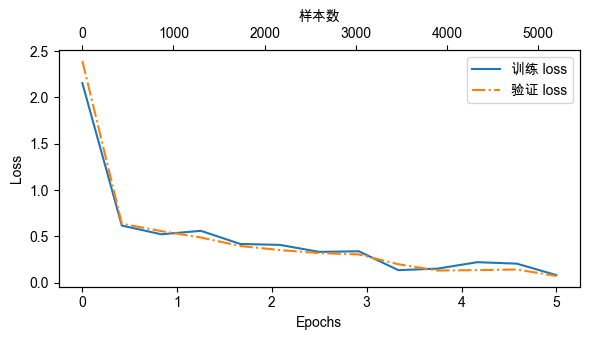

In [23]:
def plot_values(epochs_seen, examples_seen, train_values, val_values, label="loss"):
    fig, ax1 = plt.subplots(figsize=(6, 3.5))
    ax1.plot(epochs_seen, train_values, label=f"训练 {label}")
    ax1.plot(epochs_seen, val_values, linestyle="-.", label=f"验证 {label}")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel(label.capitalize())
    ax1.legend()

    ax2 = ax1.twiny()
    ax2.plot(examples_seen, train_values, alpha=0)
    ax2.set_xlabel("样本数")

    fig.tight_layout()
    plt.show()


# 绘制损失曲线
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_losses))
plot_values(epochs_tensor, examples_seen_tensor, train_losses, val_losses, label="loss")

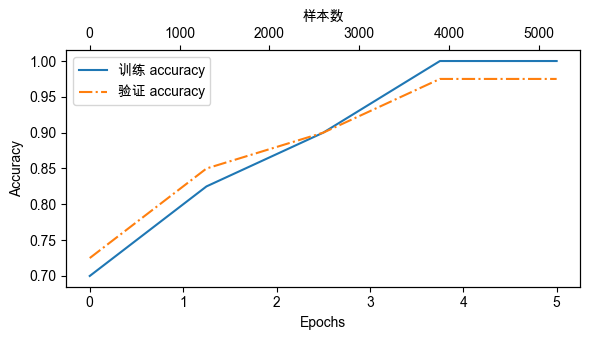

In [24]:
# 绘制准确率曲线
epochs_tensor = torch.linspace(0, num_epochs, len(train_accs))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_accs))
plot_values(epochs_tensor, examples_seen_tensor, train_accs, val_accs, label="accuracy")

### 最终评估

In [25]:
# 在完整数据集上计算最终准确率
train_accuracy = calc_accuracy_loader(train_loader, model, device)
val_accuracy = calc_accuracy_loader(val_loader, model, device)
test_accuracy = calc_accuracy_loader(test_loader, model, device)

print(f"训练准确率: {train_accuracy*100:.2f}%")
print(f"验证准确率: {val_accuracy*100:.2f}%")
print(f"测试准确率: {test_accuracy*100:.2f}%")

训练准确率: 97.21%
验证准确率: 97.32%
测试准确率: 95.67%


> 💡 **观察：** 测试集准确率略低于训练/验证集，这说明模型存在轻微的过拟合。可以通过增大 `drop_rate` 或 `weight_decay` 来缓解。

### ✏️ 练习

1. 调整学习率（如 1e-4, 1e-5），观察训练曲线和最终准确率的变化。
2. 增加 `num_epochs` 到 10，观察是否出现过拟合（训练 loss 下降但验证 loss 上升）。
3. **进阶**：添加梯度裁剪（`torch.nn.utils.clip_grad_norm_`），看看对训练稳定性有什么影响。

In [26]:
# 练习：学习率、epoch、梯度裁剪实验
# 这些实验会重复训练 GPT-2 分类器，耗时较长；需要时把 RUN_EXTRA_TRAINING 改为 True。
RUN_EXTRA_TRAINING = False


def train_classifier_with_grad_clip(model, train_loader, val_loader, optimizer, device,
                                    num_epochs, eval_freq, eval_iter, max_grad_norm=None):
    train_losses, val_losses, train_accs, val_accs = [], [], [], []
    examples_seen, global_step = 0, -1

    for epoch in range(num_epochs):
        model.train()
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward()
            if max_grad_norm is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
            optimizer.step()

            examples_seen += input_batch.shape[0]
            global_step += 1

            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")

        train_accuracy = calc_accuracy_loader(train_loader, model, device, num_batches=eval_iter)
        val_accuracy = calc_accuracy_loader(val_loader, model, device, num_batches=eval_iter)
        train_accs.append(train_accuracy)
        val_accs.append(val_accuracy)
        print(f"Training accuracy: {train_accuracy*100:.2f}% | Validation accuracy: {val_accuracy*100:.2f}%")

    return train_losses, val_losses, train_accs, val_accs, examples_seen


def run_finetuning_experiment(name, strategy="last_block", lr=5e-5, num_epochs=5, max_grad_norm=None):
    print(f"\n===== {name} =====")
    experiment_model = make_classifier_from_pretrained(strategy).to(device)
    optimizer = torch.optim.AdamW(
        (p for p in experiment_model.parameters() if p.requires_grad),
        lr=lr,
        weight_decay=0.1,
    )
    history = train_classifier_with_grad_clip(
        experiment_model, train_loader, val_loader, optimizer, device,
        num_epochs=num_epochs, eval_freq=50, eval_iter=5,
        max_grad_norm=max_grad_norm,
    )
    train_acc = calc_accuracy_loader(train_loader, experiment_model, device)
    val_acc = calc_accuracy_loader(val_loader, experiment_model, device)
    test_acc = calc_accuracy_loader(test_loader, experiment_model, device)
    print(f"最终准确率 → train: {train_acc*100:.2f}% | val: {val_acc*100:.2f}% | test: {test_acc*100:.2f}%")
    return {
        "name": name,
        "model": experiment_model,
        "history": history,
        "train_acc": train_acc,
        "val_acc": val_acc,
        "test_acc": test_acc,
    }

experiment_plan = [
    {"name": "lr=1e-4", "strategy": "last_block", "lr": 1e-4, "num_epochs": 5, "max_grad_norm": None},
    {"name": "lr=1e-5", "strategy": "last_block", "lr": 1e-5, "num_epochs": 5, "max_grad_norm": None},
    {"name": "10 epochs + grad clip", "strategy": "last_block", "lr": 5e-5, "num_epochs": 10, "max_grad_norm": 1.0},
    {"name": "head only", "strategy": "head_only", "lr": 5e-5, "num_epochs": 5, "max_grad_norm": 1.0},
    {"name": "full fine-tuning", "strategy": "full", "lr": 1e-5, "num_epochs": 3, "max_grad_norm": 1.0},
]

if RUN_EXTRA_TRAINING:
    experiment_results = [run_finetuning_experiment(**config) for config in experiment_plan]
    summary_df = pd.DataFrame([
        {
            "实验": result["name"],
            "train_acc": result["train_acc"],
            "val_acc": result["val_acc"],
            "test_acc": result["test_acc"],
        }
        for result in experiment_results
    ])
    display(summary_df)
else:
    print("额外训练实验已跳过。把 RUN_EXTRA_TRAINING 改为 True 后重新运行本单元即可执行。")
    display(pd.DataFrame(experiment_plan))

额外训练实验已跳过。把 RUN_EXTRA_TRAINING 改为 True 后重新运行本单元即可执行。


,name,strategy,lr,num_epochs,max_grad_norm
0,lr=1e-4,last_block,0.00010,5,NaN
1,lr=1e-5,last_block,0.00001,5,NaN
2,10 epochs + grad clip,last_block,0.00005,10,1.0
3,head only,head_only,0.00005,5,1.0
4,full fine-tuning,full,0.00001,3,1.0


---

## 6.8 使用分类器 ⭐

训练完成后，我们可以用模型对新短信进行分类：

In [27]:
def classify_review(text, model, tokenizer, device, max_length=None, pad_token_id=50256):
    """对一条文本进行 spam/not spam 分类"""
    model.eval()

    input_ids = tokenizer.encode(text)
    supported_context_length = model.pos_emb.weight.shape[0]

    input_ids = input_ids[:min(max_length, supported_context_length)]
    input_ids += [pad_token_id] * (max_length - len(input_ids))
    input_tensor = torch.tensor(input_ids, device=device).unsqueeze(0)

    with torch.no_grad():
        logits = model(input_tensor)[:, -1, :]
    predicted_label = torch.argmax(logits, dim=-1).item()

    return "spam" if predicted_label == 1 else "not spam"

In [28]:
# 测试：垃圾短信
text_1 = (
    "You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award."
)
print(f"\"...{text_1[:50]}...\" → {classify_review(text_1, model, tokenizer, device, max_length=train_dataset.max_length)}")

# 测试：正常短信
text_2 = (
    "Hey, just wanted to check if we're still on"
    " for dinner tonight? Let me know!"
)
print(f"\"...{text_2[:50]}...\" → {classify_review(text_2, model, tokenizer, device, max_length=train_dataset.max_length)}")

"...You are a winner you have been specially selected ..." → spam
"...Hey, just wanted to check if we're still on for di..." → not spam


### 保存和加载模型

In [29]:
# 保存微调后的模型
torch.save(model.state_dict(), "spam_classifier.pth")
print("模型已保存为 spam_classifier.pth")

# 加载方式示例（在新的 session 中使用）：
# model = GPTModel(BASE_CONFIG)
# model.out_head = torch.nn.Linear(in_features=768, out_features=2)
# model.load_state_dict(torch.load("spam_classifier.pth", map_location=device, weights_only=True))
# model.eval()

模型已保存为 spam_classifier.pth


### ✏️ 练习

1. 自己编写几条短信（中文或英文），测试分类器的效果。
2. 模型对哪类短信容易判断错误？分析原因。
3. **进阶**：将保存的模型在新的 notebook 中加载并使用。

In [30]:
# 练习 1：自定义短信测试
custom_messages = [
    "Free entry in a weekly competition! Text WIN to 80086 now.",
    "Can you pick up milk on your way home?",
    "URGENT! Your account has won a $500 gift card. Claim now.",
    "今晚 7 点一起吃饭吗？我订了餐厅。",
    "限时中奖通知：点击链接领取现金奖励！",
]

for message in custom_messages:
    prediction = classify_review(
        message, model, tokenizer, device,
        max_length=train_dataset.max_length,
    )
    print(f"{prediction:>8} | {message}")


# 练习 2：查看测试集中容易判断错误的样本
mistakes = []
for _, row in test_df.iterrows():
    prediction = classify_review(
        row["Text"], model, tokenizer, device,
        max_length=train_dataset.max_length,
    )
    predicted_label = 1 if prediction == "spam" else 0
    if predicted_label != row["Label"]:
        mistakes.append({
            "true_label": "spam" if row["Label"] == 1 else "not spam",
            "predicted": prediction,
            "text": row["Text"],
        })

print(f"\n测试集错误样本数: {len(mistakes)} / {len(test_df)}")
for mistake in mistakes[:10]:
    print(f"真实={mistake['true_label']:<8} 预测={mistake['predicted']:<8} 文本={mistake['text'][:140]}")

print("\n常见误判原因:")
print("1. 很短的 spam 缺少明显关键词，容易被判成 not spam。")
print("2. 正常短信如果包含 win/free/call/urgent 等词，可能被误判成 spam。")
print("3. GPT-2 主要按英文 BPE 训练；中文短信 token 化更碎，效果通常不如英文稳定。")


# 练习 3：在新 session 中加载已保存的分类模型并使用
def load_spam_classifier(model_path, base_config, device):
    loaded_model = GPTModel(base_config)
    loaded_model.out_head = torch.nn.Linear(
        in_features=base_config["emb_dim"],
        out_features=2,
    )
    state_dict = torch.load(model_path, map_location=device, weights_only=True)
    loaded_model.load_state_dict(state_dict)
    loaded_model.to(device)
    loaded_model.eval()
    return loaded_model

loaded_model = load_spam_classifier("spam_classifier.pth", BASE_CONFIG, device)
check_message = "Congratulations, you have won a cash prize. Call now!"
print("\n加载后的模型预测:")
print(classify_review(check_message, loaded_model, tokenizer, device, max_length=train_dataset.max_length))

    spam | Free entry in a weekly competition! Text WIN to 80086 now.
not spam | Can you pick up milk on your way home?
    spam | URGENT! Your account has won a $500 gift card. Claim now.
    spam | 今晚 7 点一起吃饭吗？我订了餐厅。
    spam | 限时中奖通知：点击链接领取现金奖励！

测试集错误样本数: 13 / 300
真实=spam     预测=not spam 文本=thesmszone.com lets you send free anonymous and masked messages..im sending this message from there..do you see the potential for abuse???
真实=spam     预测=not spam 文本=Hello. We need some posh birds and chaps to user trial prods for champneys. Can i put you down? I need your address and dob asap. Ta r
真实=spam     预测=not spam 文本=Filthy stories and GIRLS waiting for your
真实=not spam 预测=spam     文本=Do u konw waht is rael FRIENDSHIP Im gving yuo an exmpel: Jsut ese tihs msg.. Evrey splleing of tihs msg is wrnog.. Bt sitll yuo can raed it
真实=spam     预测=not spam 文本=Do you realize that in about 40 years, we'll have thousands of old ladies running around with tattoos?
真实=spam     预测=not spam 文本=Money i h

---

## 6.9 完整流程回顾

In [31]:
print("""
═══════════════════════════════════════════════════════════
          第 6 章：分类微调 — 完整流程
═══════════════════════════════════════════════════════════

  1. 了解微调类型（分类 vs 指令）
     ↓
  2. 下载并准备 SMS Spam 数据集
     ↓  平衡类别 → 划分 train/val/test
  3. 创建 SpamDataset + DataLoader
     ↓  tokenize → padding → batch
  4. 加载预训练 GPT-2 权重
     ↓  验证文本生成能力
  5. 添加分类头
     ↓  冻结 backbone → 替换 out_head → 解冻最后一层
  6. 计算分类损失和准确率
     ↓  cross_entropy(logits[:, -1, :], labels)
  7. 训练分类器
     ↓  5 epochs, AdamW, lr=5e-5
  8. 使用分类器对新文本做预测
     ↓  tokenize → pad → forward → argmax
  9. 第 7 章：指令微调 — 让模型学会对话！

═══════════════════════════════════════════════════════════

关键收获:
  • 分类微调 = 冻结 backbone + 替换输出头 + 用有标签数据训练
  • 只取最后一个 token 的输出做分类（因为 causal attention）
  • 解冻最后几层可以显著提升效果
  • 只需训练约 7% 的参数就能达到 ~95% 以上的准确率
""")


═══════════════════════════════════════════════════════════
          第 6 章：分类微调 — 完整流程
═══════════════════════════════════════════════════════════

  1. 了解微调类型（分类 vs 指令）
     ↓
  2. 下载并准备 SMS Spam 数据集
     ↓  平衡类别 → 划分 train/val/test
  3. 创建 SpamDataset + DataLoader
     ↓  tokenize → padding → batch
  4. 加载预训练 GPT-2 权重
     ↓  验证文本生成能力
  5. 添加分类头
     ↓  冻结 backbone → 替换 out_head → 解冻最后一层
  6. 计算分类损失和准确率
     ↓  cross_entropy(logits[:, -1, :], labels)
  7. 训练分类器
     ↓  5 epochs, AdamW, lr=5e-5
  8. 使用分类器对新文本做预测
     ↓  tokenize → pad → forward → argmax
  9. 第 7 章：指令微调 — 让模型学会对话！

═══════════════════════════════════════════════════════════

关键收获:
  • 分类微调 = 冻结 backbone + 替换输出头 + 用有标签数据训练
  • 只取最后一个 token 的输出做分类（因为 causal attention）
  • 解冻最后几层可以显著提升效果
  • 只需训练约 7% 的参数就能达到 ~95% 以上的准确率



---

## 📝 本章核心 Checklist

学完本章后，检查你是否能回答以下问题：

- [ ] 分类微调和指令微调有什么区别？各适用于什么场景？
- [ ] 为什么要用最后一个 token 的输出做分类？
- [ ] 为什么要冻结大部分参数？只训练哪些层？
- [ ] `out_head` 替换前后，模型的输出维度有什么变化？
- [ ] `SpamDataset` 中 padding 的作用是什么？为什么用 `<|endoftext|>` 做 padding token？
- [ ] 训练中的 `calc_loss_batch` 与第5章有什么区别？
- [ ] 怎样判断模型是否过拟合？有哪些缓解方法？
- [ ] 如何保存和加载微调后的模型？

全部能回答 → 进入**第 7 章：指令微调**——让模型学会像 ChatGPT 一样对话！